Project Title :- Movies Data Analysis And Visualization

The objective of this project is to analyze movie data to understand factors affecting profitability, efficiency (ROI), and overall performance.

1. Importing Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Loading Dataset and Basic Structure

In [43]:
data  = pd.read_csv('tmdb_5000_movies.csv')

data.head()
print(data.shape)
print(data.info())
print(data.isnull().sum())

(4803, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   id                    4803 non-null   int64  
 3   keywords              4803 non-null   object 
 4   original_language     4803 non-null   object 
 5   original_title        4803 non-null   object 
 6   popularity            4803 non-null   float64
 7   production_companies  4803 non-null   object 
 8   production_countries  4803 non-null   object 
 9   release_date          4802 non-null   object 
 10  revenue               4803 non-null   int64  
 11  runtime               4801 non-null   float64
 12  spoken_languages      4803 non-null   object 
 13  status                4803 non-null   object 
 14  tagline               3959 non-null   object 
 15  title     

3. Cleaning dataset by handling missing values and removing irrelevant columns

In [44]:
data['budget'] = data['budget'].replace(0, np.nan)
data['revenue'] = data['revenue'].replace(0, np.nan)

In [45]:
NaN_Columns = data.isnull().sum()
print(NaN_Columns)

missing_value_percent = (data.isnull().sum() / len(data)) * 100
print(missing_value_percent)

budget                  1037
genres                     0
id                         0
keywords                   0
original_language          0
original_title             0
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                 1427
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64
budget                  21.590672
genres                   0.000000
id                       0.000000
keywords                 0.000000
original_language        0.000000
original_title           0.000000
popularity               0.000000
production_companies     0.000000
production_countries     0.000000
release_date             0.020820
revenue                 29.710598
runtime                  0.041641
spoken_languages         0.000000
status                 

In [46]:
# removing unecessary columns
data.drop(['original_language', 'spoken_languages', 'keywords'], axis=1, inplace=True)
data.drop(['tagline', 'status', 'title'], axis=1, inplace=True)


In [47]:
data = data.dropna(subset=['budget', 'revenue'])
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3229 entries, 0 to 4798
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                3229 non-null   float64
 1   genres                3229 non-null   object 
 2   id                    3229 non-null   int64  
 3   original_title        3229 non-null   object 
 4   popularity            3229 non-null   float64
 5   production_companies  3229 non-null   object 
 6   production_countries  3229 non-null   object 
 7   release_date          3229 non-null   object 
 8   revenue               3229 non-null   float64
 9   runtime               3229 non-null   float64
 10  vote_average          3229 non-null   float64
 11  vote_count            3229 non-null   int64  
dtypes: float64(5), int64(2), object(5)
memory usage: 327.9+ KB
None


In [48]:
duplicate_count = data.map(lambda x: tuple(x) if isinstance(x, list) else x).duplicated().sum()
duplicate_count

0

4. Creating new features like Profit and ROI

In [49]:
data['profit'] = data['revenue'] - data['budget']
data['roi'] = (data['profit']/data['budget'])
data['movie_category'] = data['roi'].apply(lambda x: "Hit" if x > 2 else ("Flop" if x < 0 else "Average"))

data.head()

,budget,genres,id,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,vote_average,vote_count,profit,roi,movie_category
0,237000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,Avatar,150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",10-12-2009,2.787965e+09,162.0,7.2,11800,2.550965e+09,10.763566,Hit
1,300000000.0,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,Pirates of the Caribbean: At World's End,139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",19-05-2007,9.610000e+08,169.0,6.9,4500,6.610000e+08,2.203333,Hit
2,245000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,Spectre,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",26-10-2015,8.806746e+08,148.0,6.3,4466,6.356746e+08,2.594590,Hit
3,250000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,The Dark Knight Rises,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",16-07-2012,1.084939e+09,165.0,7.6,9106,8.349391e+08,3.339756,Hit
4,260000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,John Carter,43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",07-03-2012,2.841391e+08,132.0,6.1,2124,2.413910e+07,0.092843,Average


In [50]:
print("Maximum Profit: ", data['profit'].max(), "\nMinimum Profit: ", data['profit'].min())
print("\nMaximum ROI: ", data['roi'].max(), "\nMinimum ROI: ", data['roi'].min())

print("\nCount of Movies in Each Category: \n", data['movie_category'].value_counts())

Maximum Profit:  2550965087.0 
Minimum Profit:  -165710090.0

Maximum ROI:  8499999.0 
Minimum ROI:  -0.9999994782608695

Count of Movies in Each Category: 
 movie_category
Hit        1274
Average    1166
Flop        789
Name: count, dtype: int64


5. Exploratory Data Analysis

Analyzing profitability across genres

In [60]:
import ast

# Parse genres column to extract genre names
data['genres_list'] = data['genres'].apply(lambda x: [genre['name'] for genre in ast.literal_eval(x)] if x != '[]' else [])

# Explode the dataframe to have one row per genre per movie
data_exploded = data.explode('genres_list')

# Calculate profit
data_exploded['profit'] = data_exploded['revenue'] - data_exploded['budget']

# Group by genre and calculate average profit
average_profit_by_genre = data_exploded.groupby('genres_list')['profit'].mean().sort_values(ascending=False)

print(average_profit_by_genre)

genres_list
Animation          1.980907e+08
Adventure          1.707142e+08
Fantasy            1.626755e+08
Family             1.575881e+08
Science Fiction    1.259568e+08
Action             1.144244e+08
Comedy             7.232391e+07
Thriller           6.923375e+07
Romance            6.426381e+07
Mystery            6.330812e+07
War                5.979416e+07
Music              5.509401e+07
Crime              5.314782e+07
Drama              5.194328e+07
Horror             4.716959e+07
History            4.016241e+07
Western            3.029081e+07
Documentary        2.040826e+07
Foreign           -2.249849e+06
Name: profit, dtype: float64


In [72]:
# Calculate ROI (Return on Investment) as profit / budget, handling division by zero
data_exploded['roi'] = data_exploded.apply(lambda row: row['profit'] / row['budget'] if row['budget'] > 0 else None, axis=1)

# Group by genre and calculate average ROI
average_roi_by_genre = data_exploded.groupby('genres_list')['roi'].mean().sort_values(ascending=False)

print(average_roi_by_genre)

genres_list
Comedy             7662.066247
Drama              5907.024215
Horror             3076.422678
Thriller           1073.897187
Documentary         159.106742
Mystery              66.761837
Music                 5.435301
Animation             5.087650
Science Fiction       4.926710
Fantasy               4.817778
Family                4.157520
Romance               4.089232
Western               3.901748
War                   3.899900
Adventure             3.458006
Crime                 3.238685
History               3.042294
Action                2.579040
Foreign              -0.539253
Name: roi, dtype: float64


In [83]:
# Risky genre 
risky_genre = average_roi_by_genre.idxmin()
print("\nMost Risky Genre: ", risky_genre)


Most Risky Genre:  Foreign


Insight:-

Animation movies earn the highest profit, which shows they have strong demand worldwide. Comedy movies, on the other hand, give better returns compared to their budget, so they are more efficient. Some genres are riskier because their performance is not consistent.

Analyzing Relationship between Budget And Revenue

In [84]:
print("Correlation between Budget and Revenue: ", data['budget'].corr(data['revenue']))

Correlation between Budget and Revenue:  0.705399330678138


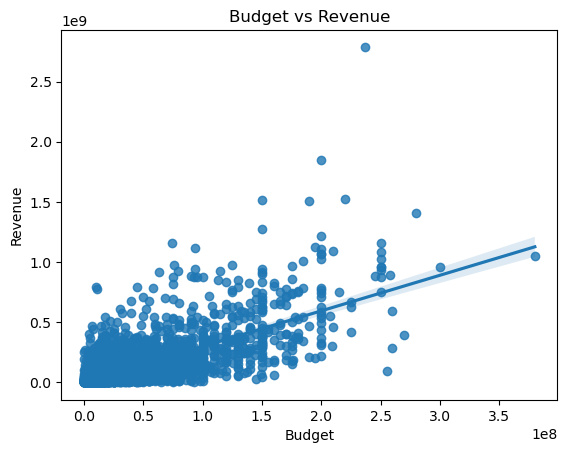

In [85]:
sns.regplot(x='budget', y='revenue', data=data)
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

Insight:-

Movies with higher budgets usually earn more revenue, so there is a clear positive trend. But this does not mean every big-budget movie is successful, because some of them still fail due to different factors.

Analyzing Relationship between Rating and ROI

In [86]:
print("Correlation between Rating and Roi: ", data["vote_average"].corr(data['roi']))

Correlation between Rating and Roi:  0.032523110506762945


Insight:-

There is almost no strong relationship between movie ratings and ROI. This means a movie can have a high rating but still not make good returns, because factors like budget, marketing, and audience reach also play an important role.

Year wise Analysis

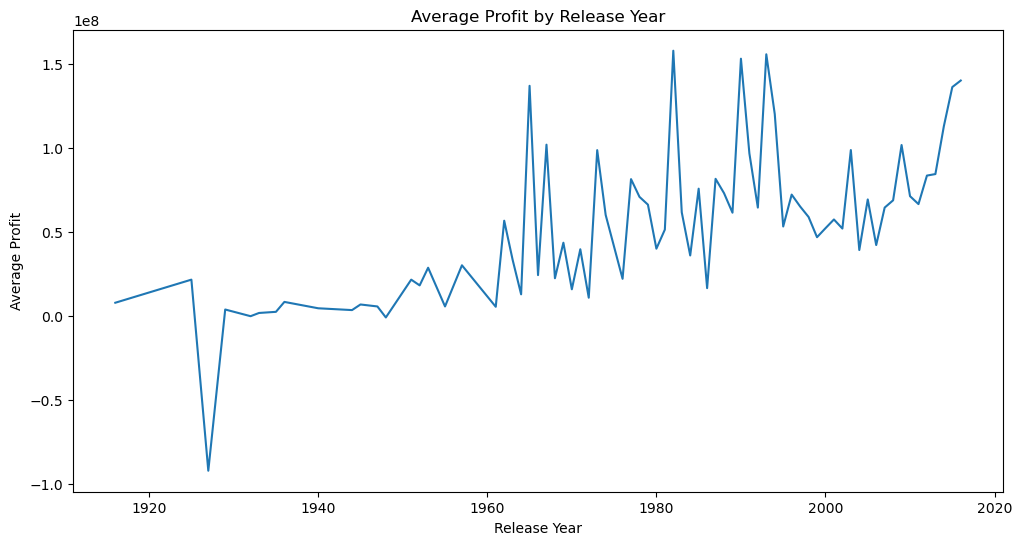

In [87]:
# Year wise profit trend analysis
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')
data['release_year'] = data['release_date'].dt.year
yearly_profit = data.groupby('release_year')['profit'].mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_profit.index, y=yearly_profit.values)
plt.title('Average Profit by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Profit')
plt.show()

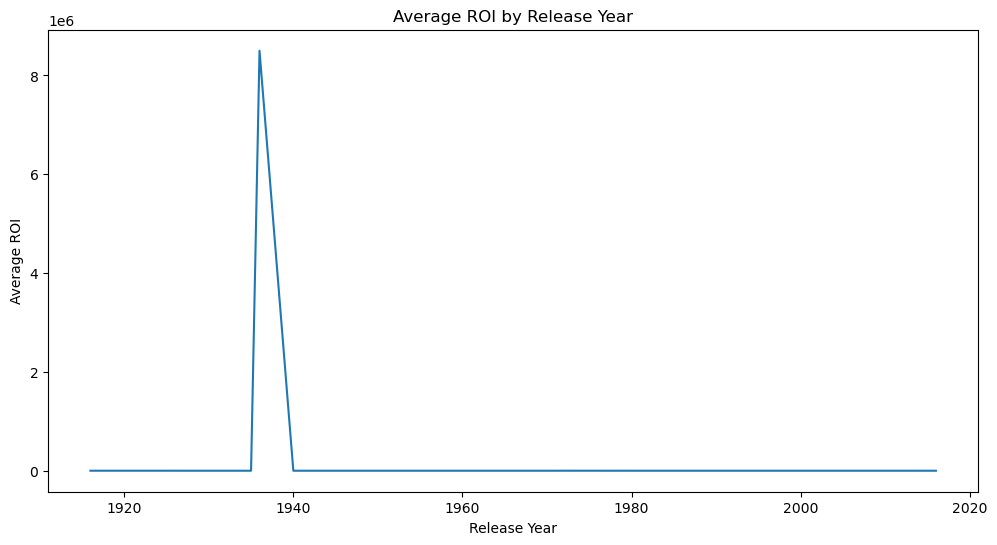

In [88]:
# Year wise ROI trend analysis
yearly_roi = data.groupby('release_year')['roi'].mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_roi.index, y=yearly_roi.values)
plt.title('Average ROI by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average ROI')
plt.show()

Insight:- 

The movie industry shows overall growth in profit over time, but the trend is not stable. There are many ups and downs across different years, which indicates that performance depends on multiple factors like audience response, budget, and timing. Also, some extreme values (outliers) can affect the yearly averages.

6. Data Visualization

Genre vs Average Profit

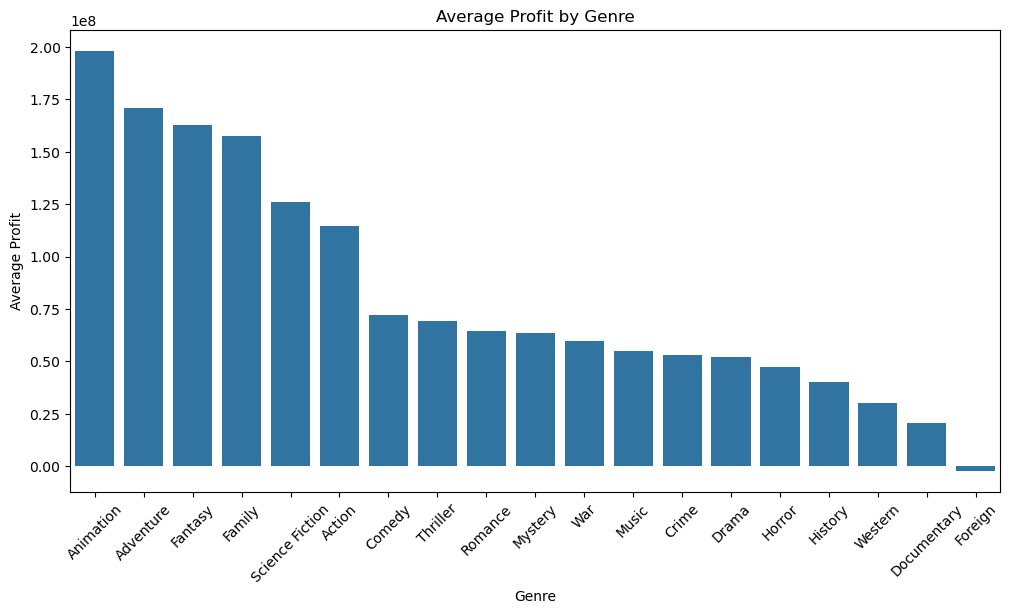

In [93]:
# Bar plot for genre vs average profit
plt.figure(figsize=(12, 6))
sns.barplot(x=average_profit_by_genre.index, y=average_profit_by_genre.values)
plt.title('Average Profit by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.show()

Insight:-

Animation movies generate the highest profit, which shows strong global demand and large audience reach. Genres like Adventure and Fantasy also perform well, while genres like Documentary and Foreign generate very low or even negative profits, making them riskier choices.

Budget vs Revenue Relationship

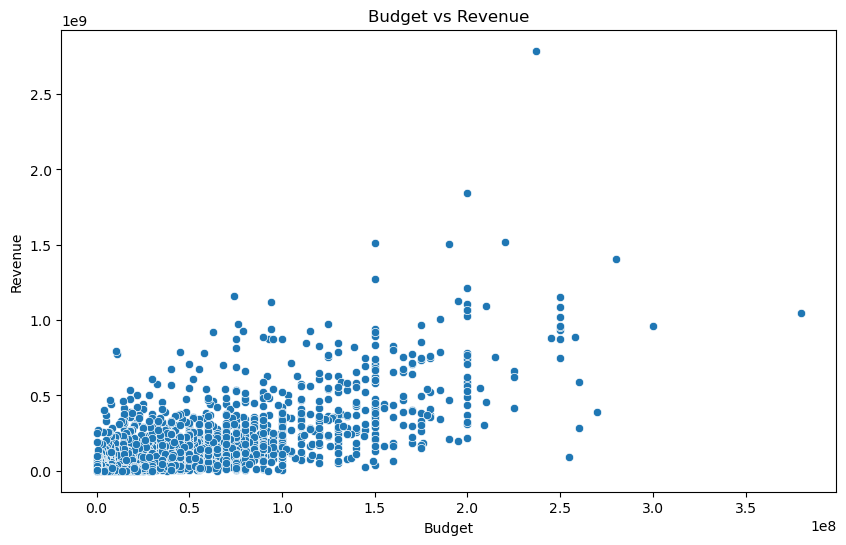

In [94]:
#Budget vs Revenue Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget', y='revenue', data=data)
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

Insight:-

There is a clear positive relationship between budget and revenue, meaning higher budget movies generally earn more. However, the spread of points shows that not all big-budget movies are successful, and some low-budget movies also perform well, indicating variability in outcomes.

ROI Distribution

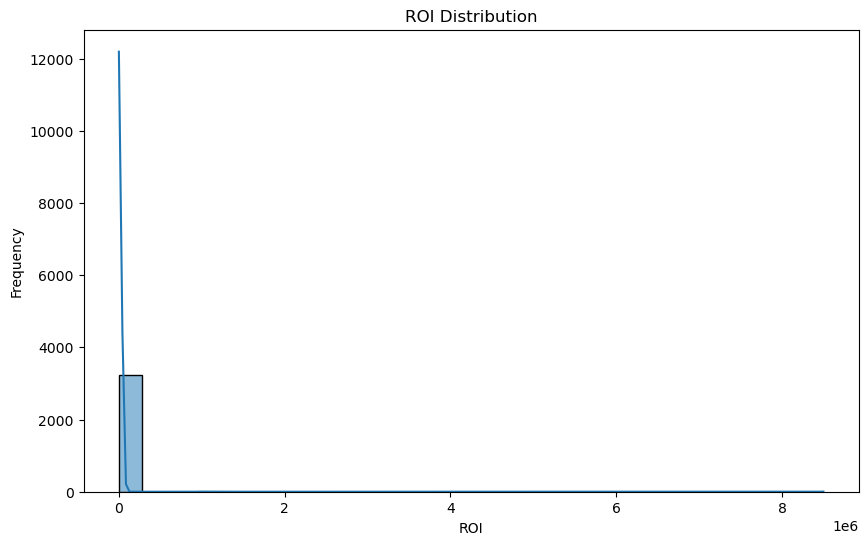

In [95]:
#Roi Distribution Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data['roi'], bins=30, kde=True)
plt.title('ROI Distribution')
plt.xlabel('ROI')
plt.ylabel('Frequency')
plt.show()

Insight:-

The ROI distribution is highly skewed due to a few extreme values. Most movies have ROI close to zero, meaning they earn moderate or low returns, while only a small number of movies generate extremely high returns, which creates a long tail in the distribution.

Year-Wise Profit Trend

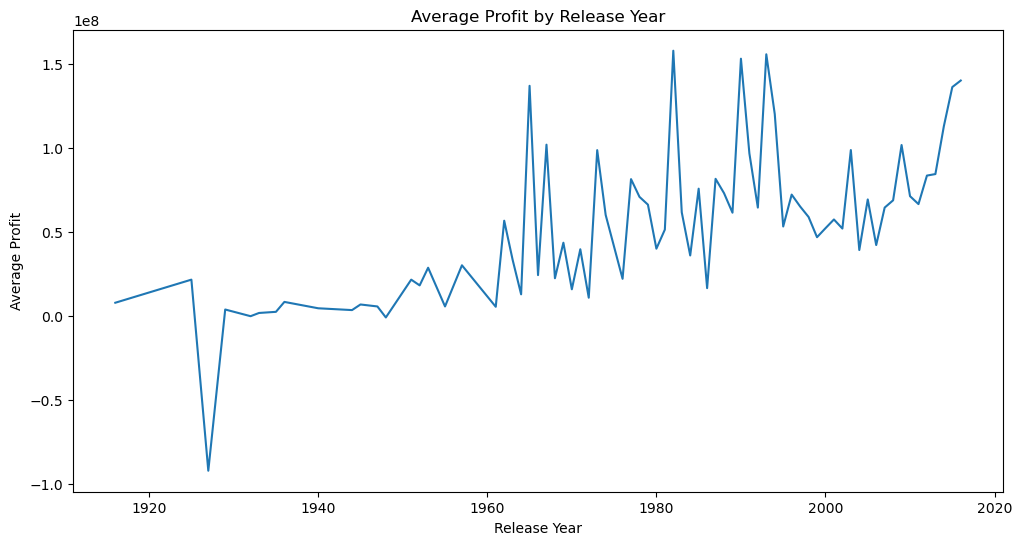

In [96]:
# Year-wise Profit Trend Analysis
yearly_profit = data.groupby('release_year')['profit'].mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_profit.index, y=yearly_profit.values)
plt.title('Average Profit by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Profit')
plt.show()


Insight:-

The movie industry shows an overall increase in profit over time, but the trend is not consistent. There are many ups and downs across different years, indicating that movie performance depends on multiple factors like audience preference, competition, and release timing.

7. Key Insights:-

a. Higher budget movies generally generate more revenue, but they do not guarantee success as there are  many exceptions and failures.

b. Animation genre produces the highest profit, while comedy movies are more efficient in terms of ROI due to lower production costs.

c. There is almost no strong relationship between movie ratings and ROI, which means highly rated movies do not always generate high returns.

d. The ROI distribution is highly skewed, showing that only a few movies generate extremely high returns while most movies have moderate or low ROI.

e. The movie industry has grown over time, but performance remains inconsistent due to factors like audience preference, competition, and release timing.

8. Conclusion

This project analyzed movie data to understand the factors affecting profitability and efficiency. The analysis showed that while higher budgets can lead to higher revenue, success is not guaranteed. Genre plays an important role, with animation generating high profits and comedy providing better ROI. It was also observed that ratings do not strongly impact financial returns, and the industry shows growth over time but remains inconsistent. Overall, this project highlights the importance of data-driven decision making in the movie industry